# From unstructure invoices document to buisness insights in minutes

This Jupyter notebook demonstrates a streamlined workflow for extracting valuable insights from invoice documents, leveraging the strengths of Google Cloud's key technologies:

- BigQuery: A scalable data warehouse for storing and querying structured invoice data.
- Document AI: An AI-powered service to automatically extract key information (e.g., invoice number, dates, line items, totals) from unstructured invoice PDFs or images.
- Generative AI (Gemini): A sophisticated language model capable of summarizing, analyzing



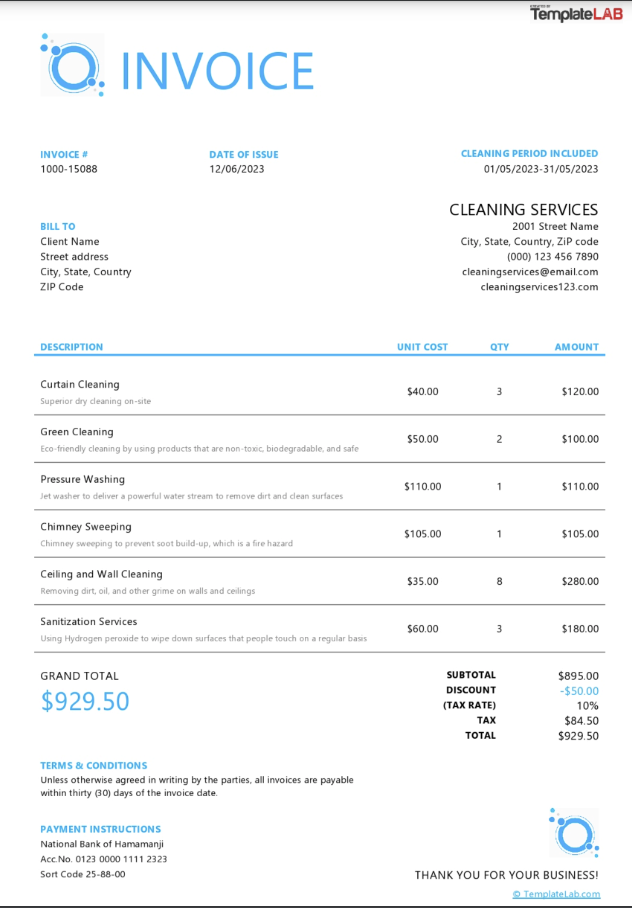

Initialize notebook level variables

In [1]:
# initialize PROJECT_ID
import os
PROJECT_ID = os.environ["GOOGLE_CLOUD_PROJECT"]

%pip install --upgrade --user --quiet \
    google-cloud-aiplatform \
    google-cloud-bigquery

Clear all previoulsy created content.

In [ ]:
################################
## delete the project
################################
# !bq rm -r -f $PROJECT_ID:gemini_demo

################################
## delete individual resources
################################

## delete tables
!bq rm -f "document_ai.document_processed_embedded"
!bq rm -f "document_ai.document_processed"
!bq rm -f "document_ai.invoice_object_table"

## delete models
!bq rm -f --model "document_ai.embedding_model"
!bq rm -f --model "document_ai.gemini_flash_model"
!bq rm -f --model "document_ai.lohk_invoice_processor"

## delete everything in a dataset
!bq rm -r -f -d "lohk-da-coaching:document_ai"

## delete connection
!bq rm --connection --project_id=$PROJECT_ID --location=us gemini_conn

BigQuery error in rm operation: Not found: Connection projects/lohk-da-
coaching/locations/us/connections/gemini_conn


Create a new dataset called **document_ai** to contain all resources created in this notebook.

In [ ]:
# create a new dataset
%%bigquery
CREATE SCHEMA `lohk-da-coaching.document_ai` OPTIONS (location = 'US');


Create the Gemini model and text embedding model that will be used in this notebook

In [3]:
%%bigquery

# create gemini vision pro model
CREATE OR REPLACE MODEL `document_ai.gemini_flash_model`
REMOTE WITH CONNECTION DEFAULT
OPTIONS(endpoint='gemini-2.0-flash-001');

# create text embedding model
CREATE OR REPLACE  MODEL `document_ai.embedding_model`
REMOTE WITH CONNECTION DEFAULT
OPTIONS(endpoint = 'text-embedding-005');

Query is running:   0%|          |

""


Create the invoice processor model that links to the invoice document AI that was already created.

In [4]:
# create a document AI BQ model
%%bigquery
CREATE OR REPLACE MODEL `lohk-da-coaching.document_ai.lohk_invoice_processor`
REMOTE WITH CONNECTION `us.vertex_llm`
OPTIONS (
  REMOTE_SERVICE_TYPE = 'CLOUD_AI_DOCUMENT_V1',
  DOCUMENT_PROCESSOR = 'projects/458398081798/locations/us/processors/bea2aeb9d9f216d3/processorVersions/pretrained-invoice-v2.0-2023-12-06'
);

Query is running:   0%|          |

""


## Access unstructured data in BigQuery

Create a new object table to point to invoice PDF files in a storage bucket

In [5]:
# invoices are stored in gs://lohk-da-demo/documentAI
%%bigquery
CREATE OR REPLACE EXTERNAL TABLE `document_ai.invoice_object_table`
WITH CONNECTION `us.vertex_llm`
OPTIONS(
  object_metadata = 'SIMPLE',
  uris = ['gs://lohk-da-demo/documentAI/*']
);

# preview the table content
SELECT * FROM `document_ai.invoice_object_table` LIMIT 10;

Query is running:   0%|          |

Downloading:   0%|          |

,uri,generation,content_type,size,md5_hash,updated,metadata
0,gs://lohk-da-demo/documentAI/citizenM-invoice-...,1712938998992975,application/pdf,92573,80623a1fc6ca3a1b429fbfea87ea03b4,2024-04-12 16:23:19.038000+00:00,[]
1,gs://lohk-da-demo/documentAI/invoice1.pdf,1717184230684357,application/pdf,421093,265c3602eb283b855e45665217e70758,2024-05-31 19:37:10.723000+00:00,[]
2,gs://lohk-da-demo/documentAI/invoice2.pdf,1717184264504889,application/pdf,619796,658f619232f9e78399b9adb4b583fb46,2024-05-31 19:37:44.542000+00:00,[]
3,gs://lohk-da-demo/documentAI/invoice3.pdf,1717184264281157,application/pdf,285251,0ef5e7bf15063bd6b00ae9c6fa37f4a0,2024-05-31 19:37:44.325000+00:00,[]
4,gs://lohk-da-demo/documentAI/invoice4.pdf,1717184264449256,application/pdf,554785,6c71702b0ddaf8e0f5254aa2b560c528,2024-05-31 19:37:44.493000+00:00,[]
5,gs://lohk-da-demo/documentAI/invoice5.pdf,1717184265336391,application/pdf,274957,86c65fb7650cd1cfaadc980a1e9656ba,2024-05-31 19:37:45.374000+00:00,[]
6,gs://lohk-da-demo/documentAI/invoice6.pdf,1717184265800931,application/pdf,611885,dd33f66f7be62964ff196f842b84bb4c,2024-05-31 19:37:45.838000+00:00,[]
7,gs://lohk-da-demo/documentAI/invoice7.pdf,1717184266069729,application/pdf,993543,12a774e6112a4311ec9ea270f15d6eba,2024-05-31 19:37:46.136000+00:00,[]


## We are all set to process all invoices with Google's advanced document AI

Simply link BigQuery the document AI model, and then point it to the object table

In [6]:
# process invoice PDF with document AI and store the result in a table
%%bigquery
CREATE OR REPLACE TABLE `lohk-da-coaching.document_ai.document_processed`
AS
SELECT * except (ml_process_document_result, ml_process_document_status)
FROM
  ML.PROCESS_DOCUMENT(
    MODEL `lohk-da-coaching.document_ai.lohk_invoice_processor`,
    TABLE `lohk-da-coaching.document_ai.invoice_object_table`);

# preview the table content
SELECT * FROM `lohk-da-coaching.document_ai.document_processed` LIMIT 10;

Query is running:   0%|          |

Downloading:   0%|          |

,invoice_type,currency,due_date,invoice_date,invoice_id,net_amount,purchase_order,receiver_name,receiver_tax_id,supplier_iban,...,supplier_email,supplier_phone,supplier_website,uri,generation,content_type,size,md5_hash,updated,metadata
0,,*,None,"25 Jul, 2021",1627147360-22,78.57,None,Ayushi Saini,None,None,...,hello@myglamm.com,,myglamm.com,gs://lohk-da-demo/documentAI/invoice7.pdf,1717184266069729,application/pdf,993543,12a774e6112a4311ec9ea270f15d6eba,2024-05-31 19:37:46.136000+00:00,[]
1,,None,None,09-06-2022,en73h2319825,None,169769050229,Trendy Outfits,None,None,...,None,None,None,gs://lohk-da-demo/documentAI/invoice5.pdf,1717184265336391,application/pdf,274957,86c65fb7650cd1cfaadc980a1e9656ba,2024-05-31 19:37:45.374000+00:00,[]
2,,$,12/01/18,11/11/18,#INV02081,2590.00,None,Allen Smith,None,None,...,allen@gmail.com,990-120-4560,www.plumbingstanford.com,gs://lohk-da-demo/documentAI/invoice1.pdf,1717184230684357,application/pdf,421093,265c3602eb283b855e45665217e70758,2024-05-31 19:37:10.723000+00:00,[]
3,,$,None,15/08/2028,2000-15,None,None,Olivia Wilson,None,None,...,hello@reallygreatsite.com,None,www.reallygreatsite.com,gs://lohk-da-demo/documentAI/invoice3.pdf,1717184264281157,application/pdf,285251,0ef5e7bf15063bd6b00ae9c6fa37f4a0,2024-05-31 19:37:44.325000+00:00,[]
4,,$,None,12/06/2023,1000-15088,895.00,None,None,None,0123 0000 1111 2323,...,cleaningservices@email.com,(000) 123 456 7890,TemplateLab.com,gs://lohk-da-demo/documentAI/invoice2.pdf,1717184264504889,application/pdf,619796,658f619232f9e78399b9adb4b583fb46,2024-05-31 19:37:44.542000+00:00,[]
5,,$,12/11/2023,12/10/2023,None,None,None,Jane Doe,None,None,...,johnsmith@example.com,None,None,gs://lohk-da-demo/documentAI/invoice6.pdf,1717184265800931,application/pdf,611885,dd33f66f7be62964ff196f842b84bb4c,2024-05-31 19:37:45.838000+00:00,[]
6,,None,None,19-06-2022,FKAR211234250348,None,None,None,None,None,...,customercare@ajio.com,1800-889-9991,www.relianceretail.com,gs://lohk-da-demo/documentAI/invoice4.pdf,1717184264449256,application/pdf,554785,6c71702b0ddaf8e0f5254aa2b560c528,2024-05-31 19:37:44.493000+00:00,[]
7,,€,None,23-6-2023,03201820,None,None,None,None,NL 76 HSBC 2038385556,...,None,None,www.citizenM.com,gs://lohk-da-demo/documentAI/citizenM-invoice-...,1712938998992975,application/pdf,92573,80623a1fc6ca3a1b429fbfea87ea03b4,2024-04-12 16:23:19.038000+00:00,[]


## GenAI to unlock more insights

We can use GenAI to unlock more insights, detect anomalies and curate actions to take.

First, we combine all collected information into a json column

In [7]:
# create a new column 'json_info' to store all invoice information in a json string
%%bigquery
ALTER TABLE `lohk-da-coaching.document_ai.document_processed`
ADD COLUMN json_info STRING;

# jsonify all column data of a row into a json string and store it in the new column
UPDATE `lohk-da-coaching.document_ai.document_processed` t
SET json_info = TO_JSON_STRING(t)
where true;

# preview the table content
SELECT uri, json_info FROM `lohk-da-coaching.document_ai.document_processed` LIMIT 10;

Query is running:   0%|          |

Downloading:   0%|          |

,uri,json_info
0,gs://lohk-da-demo/documentAI/invoice5.pdf,"{""invoice_type"":"""",""currency"":null,""due_date"":..."
1,gs://lohk-da-demo/documentAI/invoice6.pdf,"{""invoice_type"":"""",""currency"":""$"",""due_date"":""..."
2,gs://lohk-da-demo/documentAI/invoice1.pdf,"{""invoice_type"":"""",""currency"":""$"",""due_date"":""..."
3,gs://lohk-da-demo/documentAI/invoice4.pdf,"{""invoice_type"":"""",""currency"":null,""due_date"":..."
4,gs://lohk-da-demo/documentAI/citizenM-invoice-...,"{""invoice_type"":"""",""currency"":""€"",""due_date"":n..."
5,gs://lohk-da-demo/documentAI/invoice3.pdf,"{""invoice_type"":"""",""currency"":""$"",""due_date"":n..."
6,gs://lohk-da-demo/documentAI/invoice7.pdf,"{""invoice_type"":"""",""currency"":""*"",""due_date"":n..."
7,gs://lohk-da-demo/documentAI/invoice2.pdf,"{""invoice_type"":"""",""currency"":""$"",""due_date"":n..."


In [8]:
# retrieve description, insights and action items over the invoices
%%bigquery gemini_result
SELECT uri, ml_generate_text_llm_result AS generated_text,
FROM
  ML.GENERATE_TEXT(
    MODEL `document_ai.gemini_flash_model`,
    (
      SELECT uri, json_info,
        CONCAT('You are an invoice specialist. From the provided json, please explain what this invoice is about, what is missing as information, any anomaly, and suggest actions to take: ', json_info) AS prompt
      FROM `lohk-da-coaching.document_ai.document_processed`
      LIMIT 3
    ),
    STRUCT(
       1 AS temperature,
       2000 AS max_output_tokens,
       1 AS top_p,
       30 AS top_k,
       TRUE AS flatten_json_output));



Query is running:   0%|          |

Downloading:   0%|          |

In [9]:
from IPython.display import display, Markdown

# Convert response column to markdown and display
#print(gemini_result.head())

for index, row in gemini_result.iterrows():
    print("\n\n", row['uri'])
    display(Markdown(row['generated_text']))



 gs://lohk-da-demo/documentAI/invoice5.pdf


Okay, let's break down this invoice data.

**Invoice Summary:**

Based on the provided JSON, this appears to be an invoice for a single item:

*   **Item:** "Henzila Style Present Womens Wear Georgette saree With Blouse pics - Free Size"
*   **Quantity:** 1
*   **Unit Price:** Rs. 463.71 (Indian Rupees)
*   **Total Amount for the item:** Rs. 468.00

It's from an unspecified supplier to "Trendy Outfits".  The invoice was issued on 09-06-2022 and has invoice ID "en73h2319825", referenced by PO number "169769050229". The destination is "Ritu" at "House no 11 naale ki patti, New dheerwali jawalapur, Haridwar, Uttarakhand, 249403" while the receiver "Trendy Outfits" is based in "Roorkee, Uttarakhand, 247667".

**Missing Information:**

A significant amount of crucial information is missing, making this invoice incomplete and potentially unusable for accounting or payment purposes. Here's a detailed list:

*   **`invoice_type`:**  Is this a standard invoice, a proforma invoice, credit memo, etc.?  This is critical for understanding the document's purpose.
*   **`currency`:** While the line item uses "Rs.", the top-level `currency` field is `null`.  This should be explicitly set to "INR" (Indian Rupee) for clarity.
*   **`due_date`:**  The date by which Trendy Outfits needs to pay the invoice.  This is essential for payment tracking.
*   **`net_amount`:** The subtotal of all line items *before* taxes. It should be Rs 463.71, assuming it is calculated from quantity* unit_price
*   **`receiver_tax_id`:** The tax ID (e.g., GSTIN in India) of "Trendy Outfits".  This is often required for legal and tax compliance.
*   **`supplier_iban`:** The supplier's bank account number (IBAN) is missing, which is crucial for making payments.
*   **`supplier_name`:** The name of the company that is sending the invoice is missing.
*   **`supplier_payment_ref`:** Any specific payment reference the supplier wants the receiver to use.
*   **`supplier_registration`:** Supplier's registration number.
*   **`supplier_tax_id`:** The tax ID of the supplier.
*   **`total_amount`:** The final amount due, including taxes and any other charges.
*   **`total_tax_amount`:** The total amount of taxes charged on the invoice.
*   **`vat`:** Details of the VAT/GST, if applicable. Should describe the rate and the amount for each tax.
*   **`payment_terms`:** The agreed-upon payment terms (e.g., Net 30, Due upon receipt).
*   **`supplier_address`:** The supplier's physical address is missing.
*   **`supplier_email`:** The supplier's email address is missing.
*   **`supplier_phone`:** The supplier's phone number is missing.
*   **`supplier_website`:** The supplier's website is missing.

**Anomalies:**

*   **Inconsistent Amounts:** The line item's `amount` (Rs. 468.00) doesn't directly match the calculation from `quantity` (1) * `unit_price` (Rs. 463.71). This suggests that either an additional amount such as a tax element or other charge of Rs 4.29 is added, or that one of the amounts are incorrect
*   **Item Description:** The item description "Henzila Style Present Womens Wear Georgette saree With Blouse pics - Free Size" is descriptive, but might benefit from a more structured format, including a size and a unique product/SKU.
*   **Missing Supplier Details:** The almost total absence of supplier information is a major red flag. It makes verifying the legitimacy of the invoice difficult.

**Suggested Actions:**

1.  **Contact the Supplier:** The most important action is to contact the supplier immediately and request a *complete and corrected* invoice.  Specifically, request all the missing information mentioned above.

2.  **Verify Supplier Information:** Before making any payment, try to independently verify the supplier's information (address, phone number, tax ID) to ensure they are a legitimate business.  A simple online search can sometimes reveal inconsistencies.

3.  **Clarify the amount difference:** Clarify what elements are added to the unit_price to get the final amount.

4.  **Update Data Extraction:** Review the data extraction process. The fact that so many key fields are `null` indicates a problem with the extraction logic or the quality of the original document. Consider improving the invoice scanning process to be more accurate, or use a different service.

5.  **Reject the Invoice (if necessary):** If the supplier cannot provide a complete and accurate invoice, and you have doubts about their legitimacy, consider rejecting the invoice and refusing payment until these issues are resolved.

In summary, this invoice is severely incomplete and potentially unreliable.  Taking prompt action to obtain the missing information and verify the supplier is critical.




 gs://lohk-da-demo/documentAI/invoice6.pdf


Okay, let's break down this invoice data.

**Invoice Summary**

This invoice, dated December 10th, 2023, from John Smith (supplier) to Jane Doe (receiver) bills for a total of $2,100.  The invoice is for services rendered, specifically:

*   Web Design
*   Content Writing
*   Social Media Management
*   Graphic Design
*   SEO Optimization

The invoice due date is December 11th, 2023.

**Missing Information**

This invoice is missing a significant amount of crucial information.  Here's a breakdown:

*   **Invoice Type:** The `invoice_type` field is empty.  Is this a standard invoice, a credit note, a pro-forma invoice, etc.? This is crucial for proper accounting.
*   **Invoice ID:** The `invoice_id` is `null`.  This is absolutely essential for tracking invoices and matching them to payments.  Every invoice *must* have a unique identifier.
*   **Net Amount:** `net_amount` is `null`. The net amount is the total before taxes, and should always be specified.
*   **Purchase Order:** The `purchase_order` fields are all null for the main invoice and each line item.
*   **Receiver Tax ID:** The `receiver_tax_id` is missing. This is important for tax compliance, especially if the recipient is a business.
*   **Supplier IBAN:** The `supplier_iban` is missing.
*   **Supplier Payment Reference:** The `supplier_payment_ref` is missing.
*   **Supplier Registration:** The `supplier_registration` is missing.
*   **Supplier Tax ID:** The `supplier_tax_id` is missing. This is important for tax compliance, especially if the supplier is a business.
*   **Total Tax Amount:** The `total_tax_amount` is `null`.  If there's tax involved, the total tax amount should be clearly stated.
*   **VAT:** The `vat` array is empty. Meaning that no VAT is applied, but missing a `total_tax_amount`.
*   **Payment Terms:** The terms of payment are important to be stated
*   **Unit:** Unit is not specified for any line item.
*   **Supplier Phone:** The `supplier_phone` number is missing.
*   **Receiver Email:** The `receiver_email` is missing.
*   **Receiver Phone:** The `receiver_phone` number is missing.
*   **Amount Paid Since Last Invoice:** The `amount_paid_since_last_invoice` is `null`.

**Anomalies**

*   **Inconsistent Formatting/Lack of Totals Consistency:** The `total_amount` is provided as "2,100" but the `net_amount` and `total_tax_amount` are missing. You should check the sum of line amount : 800 + 200 + 300 + 300 + 500 = 2100. This means that no taxes have been applied. This should raise an eyebrow.
*   **Missing Tax Information:** The absence of tax-related information (`total_tax_amount` and `vat`) is a concern.  Is this invoice supposed to have VAT or other taxes applied?
*   **Currency Consistency:** Assuming currency is USD, using '2,100' should be '2100.00'.

**Suggested Actions**

1.  **Immediate Action: Contact the Supplier (John Smith).**  The most important step is to contact John Smith immediately to request a corrected invoice with the following information:
    *   **Invoice ID:**  A unique invoice number.
    *   **Invoice Type:** the type of the invoice
    *   **Net Amount:** The pre-tax subtotal of all line items.
    *   **Tax Information:** Clarification on whether VAT or other taxes apply. If so, the tax rate(s), and the `total_tax_amount`. An itemized breakdown is preferable.
    *   **Supplier Tax ID:** Provides the supplier tax identification number.
    *   **Supplier IBAN:** The IBAN is important to ensure the payment of the invoice.
    *   **Complete Payment Terms:** When this invoice is due and the payment terms
    *   **Supplier Phone Number:** To make it easier to contact

2.  **Verify Tax Obligations:**  Depending on the location of John Smith and Jane Doe, determine if VAT or other taxes should be applied to this invoice. Consult with an accountant or tax advisor if needed.

3.  **Update Accounting System:** Once you receive the corrected invoice, ensure that all the information is accurately entered into your accounting system. Create and use a proper system to track all your invoices by ID.

4.  **Review Internal Processes:**  Examine your internal processes for receiving and processing invoices.  Implement checks to ensure that all required information is present and accurate before payment.

5.  **Consider Invoice Template Enforcement:** If you are the receiver (Jane Doe), consider providing your suppliers with a template invoice to ensure they provide all the necessary information upfront.

In summary, this invoice is currently unusable for proper accounting and payment.  It's critical to get a corrected version from the supplier with the missing information.




 gs://lohk-da-demo/documentAI/invoice1.pdf


Okay, let's break down this invoice:

**Invoice Summary**

This is an invoice (#INV02081) from Stanford Plumbing & Heating to Allen Smith, dated November 11, 2018, with a due date of December 1, 2018. The invoice is for plumbing services and materials provided, including the installation of a kitchen sink, a Toto sink, a Worcester greenstar magnetic system filter, a Nest smart thermostat, and a Worcester Greenstar 301. The net amount is $2590.00, tax is $304.80 and the total amount due is $2,844.80. Payment terms are 20 days via PayPal.

**Missing Information**

*   **Supplier Tax ID:** The supplier's tax ID is missing. This is important for verification and tax compliance for the receiver.
*   **Supplier IBAN/Payment Ref:** While PayPal is specified, the PayPal details are missing.
*   **VAT Information:** The `vat` field is empty. More details about how the tax was calculated should be present.
*   **Invoice Type:** is empty

**Anomalies & Potential Issues**

*   **Currency Consistency USD:** The invoice uses "$" as currency, but it's implicitly assumed to be USD. Clarification could be a good idea.
*   **Total Amount Calculation:** Needs to be rechecked to confirm that is the exact sum of each line items + the tax amount.
*   **Unit Field:** Each item on the list has a null unit. This should be updated by unit(s)

**Actions to Take**

1.  **Contact Stanford Plumbing & Heating:**
    *   Request the supplier's full tax ID.
    *   Request all information about payment via Paypal
    *   Ask how the $304.80 in tax was calculated. Request a breakdown of the tax rate(s) applied and the taxable amounts.
    *   Verify the total amount calculation.

2.    **Missing information from receiver info**: No receiver email



## Semantic search on our documents with just 2 commands

AI semantic search is essential for getting insights from documents because it goes beyond simple keyword matching and understands the meaning and context behind words and phrases. This enables it to:

1. Uncover hidden relationships: Semantic search can identify connections between concepts that might not be explicitly stated, revealing deeper insights and patterns within the data.

2. Improve relevance: By understanding the intent behind a query, semantic search delivers more relevant results, even if the exact keywords are not present in the document.

3. Handle ambiguity: Semantic search can disambiguate words with multiple meanings, ensuring that the results align with the intended context.

4. Support complex queries: Semantic search can process complex questions and provide accurate answers, even when the information is scattered across multiple documents.

5. Enhance personalization: By analyzing user behavior and preferences, semantic search can tailor results to individual needs, making the search experience more efficient and effective.

6. Enable knowledge discovery: Semantic search can help users discover new information and connections they might not have been aware of, leading to new insights and ideas.

In [10]:
# generate embeddings
%%bigquery
CREATE OR REPLACE TABLE `lohk-da-coaching.document_ai.document_processed_embedded`
AS SELECT uri, json_info, text_embedding
FROM
  ML.GENERATE_TEXT_EMBEDDING(
    MODEL `document_ai.embedding_model`,
    (SELECT uri, json_info, json_info as content
      FROM `lohk-da-coaching.document_ai.document_processed` limit 10
    ),
    STRUCT(TRUE AS flatten_json_output)
  );

SELECT * FROM `lohk-da-coaching.document_ai.document_processed_embedded` LIMIT 5;

Query is running:   0%|          |

Downloading:   0%|          |

,uri,json_info,text_embedding
0,gs://lohk-da-demo/documentAI/invoice5.pdf,"{""invoice_type"":"""",""currency"":null,""due_date"":...","[0.019725803285837173, -0.03344101458787918, -..."
1,gs://lohk-da-demo/documentAI/invoice2.pdf,"{""invoice_type"":"""",""currency"":""$"",""due_date"":n...","[0.030868297442793846, -0.02053668163716793, -..."
2,gs://lohk-da-demo/documentAI/citizenM-invoice-...,"{""invoice_type"":"""",""currency"":""€"",""due_date"":n...","[0.04397675395011902, -0.04592011496424675, -0..."
3,gs://lohk-da-demo/documentAI/invoice4.pdf,"{""invoice_type"":"""",""currency"":null,""due_date"":...","[0.01592252589762211, -0.022114207968115807, -..."
4,gs://lohk-da-demo/documentAI/invoice1.pdf,"{""invoice_type"":"""",""currency"":""$"",""due_date"":""...","[0.011618796736001968, -0.027390699833631516, ..."


In [12]:
# search invoice using natural language
# Example 1: Which invoice has cost associated with logo design?
# Example 2: Which invoice has cleaning cost?
# Example 3: Which invoice was issued from India?
%%bigquery
SELECT
  base.uri, distance
FROM
  VECTOR_SEARCH( TABLE `lohk-da-coaching.document_ai.document_processed_embedded`, 'text_embedding', (
    SELECT
      ml_generate_embedding_result,
      content AS query
    FROM
      ML.GENERATE_EMBEDDING( MODEL `document_ai.embedding_model`,
        (
        SELECT 'Which invoice has cleaning cost?' AS content
        ))
    ),
    top_k => 5) order by distance;


Query is running:   0%|          |

Downloading:   0%|          |

,uri,distance
0,gs://lohk-da-demo/documentAI/invoice2.pdf,0.832569
1,gs://lohk-da-demo/documentAI/citizenM-invoice-...,0.905534
2,gs://lohk-da-demo/documentAI/invoice1.pdf,0.921096
3,gs://lohk-da-demo/documentAI/invoice6.pdf,0.944075
4,gs://lohk-da-demo/documentAI/invoice7.pdf,0.953866
